Використай цей шаблон в роботі з датасетом. Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань. Обмежся функціями з наведених бібліотек.

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from google.colab import files

Переглянь список .json файлів, доступних за адресою https://github.com/prust/wikipedia-movie-data/tree/master. Відкрий будь-який файл, що містить у своїй назві рік і ознайомся з його структурою. Тепер сформуй список файлів, які ти будеш завантажувати. Для формування послідовності слід використати функцію numpy.arange. Довжина послідовності має становити не менше 5 датасетів(наприклад з 1960 по 2000  рік включно). Повну адресу сформуй через конкатенацію рядків.

In [ ]:
decades_start = 1970
decades_end = 2021
step = 10
#creating a list of decades
decades = np.arange(decades_start, decades_end, step)
print(f"The length of the date sequence is {len(decades)}, from {decades_start} to {decades_end - 1} contains:")
print(decades)

json_dir = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/"
#create list to save URLs
file_list = []

#fillng a list with full URLs paths
for decade in decades:
  filename = "movies-" + str(decade) + "s.json"
  file_path = json_dir + filename
  file_list.append(file_path)
#checking result
print(file_list)

The length of the date sequence is 6, from 1970 to 2020 contains:
[1970 1980 1990 2000 2010 2020]
['https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1970s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1980s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1990s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-2000s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-2010s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-2020s.json']


Тепер послідовність дій наступна. Слід пройти по всім обраним тобою файлам, прочитати кожен як json об'єкт. Позбутись зайвих стовпців: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']. Залишити лише повні рядки(рядки без пропущених значень). Об'єднати інформацію з усіх файлів в єдиний датасет.

In [ ]:
#list for temporary store of dataframes
all_dfs = []
#columns to drop
cols_to_drop = ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']

for file in file_list:
  #reading a link as a JSON object
  response = requests.get(file)
  #decoding JSON into a Python dictionary list
  data_list = response.json()
  #droping columns (delete keys from dictionaries)
  cleaned_data_list = []
  for movie_dict in data_list:
    cleaned_movie = {
      key: value
      for key, value in movie_dict.items()
      if key not in cols_to_drop
    }
    cleaned_data_list.append(cleaned_movie)
  #saving list to temporary dataframe
  temp_df = pd.DataFrame(cleaned_data_list)
  #droping NA
  before = temp_df.shape[0]
  temp_df = temp_df.dropna(how='any', axis=0)
  after = temp_df.shape[0]
  print(f"{before - after} NA rows were dropped in {file}")
  #saving clean DF
  all_dfs.append(temp_df)
#combining all dataframes
final_df = pd.concat(all_dfs, ignore_index=True)
final_df.head()

0 NA rows were dropped in https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1970s.json
0 NA rows were dropped in https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1980s.json
0 NA rows were dropped in https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1990s.json
0 NA rows were dropped in https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-2000s.json
0 NA rows were dropped in https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-2010s.json
0 NA rows were dropped in https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-2020s.json


,title,year,cast,genres
0,A.k.a. Cassius Clay,1970,[Muhammad Ali],"[Documentary, Sports]"
1,Adam at Six A.M.,1970,"[Michael Douglas, Lee Purcell, Joe Don Baker, ...",[Drama]
2,Adam's Woman,1970,"[Beau Bridges, Jane Merrow, John Mills, James ...","[Historical, Drama]"
3,The Adventurers,1970,"[Bekim Fehmiu, Candice Bergen, Charles Aznavou...","[Drama, Adventure]"
4,Airport,1970,"[Burt Lancaster, Dean Martin, Jean Seberg, Jac...","[Disaster, Drama]"


Перевір розмір фінального датасету. він має включати 4(чотири) стовпчика. Кількість рядків залежить від обраної кількості файлів. Зьережи собі копію у вигляді csv або json файлу. Це убезпечить тебе від форс-мажорів.

In [ ]:
#checking final dataset size
print(f"Final dataset contains {final_df.shape[1]} columns and {final_df.shape[0]} rows")

Final dataset contains 4 columns and 12833 rows


In [ ]:
#save file to computer
#saving on VM
local_filename = "movies_data.csv"
final_df.to_csv(local_filename, index=False)

#download initiation
files.download(local_filename)
print("File saved successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File saved successfully!


Для json файлу не варто використовувати метод describe. Файл містить вкладені структури. Перевір вміст перших рядосків і використай метод info.

In [ ]:
#checking first rows
final_df.head()

,title,year,cast,genres
0,A.k.a. Cassius Clay,1970,[Muhammad Ali],"[Documentary, Sports]"
1,Adam at Six A.M.,1970,"[Michael Douglas, Lee Purcell, Joe Don Baker, ...",[Drama]
2,Adam's Woman,1970,"[Beau Bridges, Jane Merrow, John Mills, James ...","[Historical, Drama]"
3,The Adventurers,1970,"[Bekim Fehmiu, Candice Bergen, Charles Aznavou...","[Drama, Adventure]"
4,Airport,1970,"[Burt Lancaster, Dean Martin, Jean Seberg, Jac...","[Disaster, Drama]"


In [ ]:
#checking df.info()
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12833 entries, 0 to 12832
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   12833 non-null  object
 1   year    12833 non-null  int64 
 2   cast    12833 non-null  object
 3   genres  12833 non-null  object
dtypes: int64(1), object(3)
memory usage: 401.2+ KB


Тепер слід попрацювати з жанрами. Віднайди топ 10 жанрів за кількістю фільмів. Побудуй стовпчикову так кругову діаграму, а також виведи на екран підсумукову таблицю.

genres
Comedy             4446
Drama              4368
Action             1744
Thriller           1608
Horror             1367
Romance            1197
Crime               920
Science Fiction     867
Fantasy             611
Adventure           606
Name: count, dtype: int64


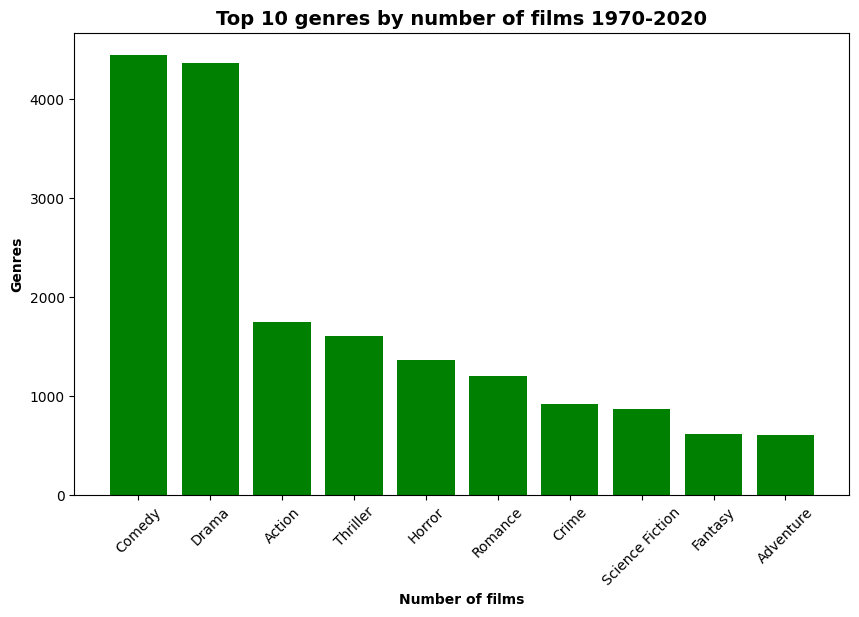

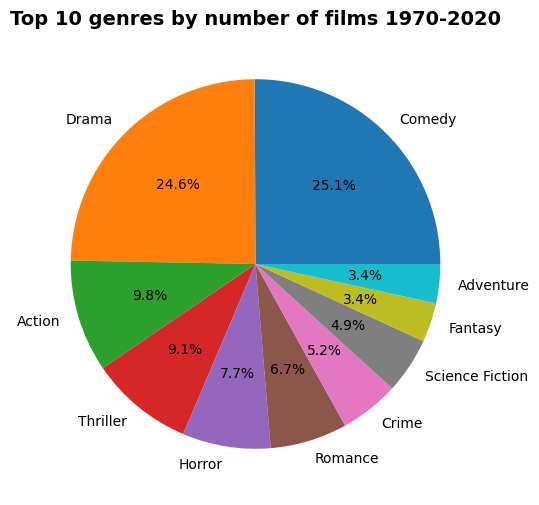

In [ ]:
#turn genres into Series
genres_exp = final_df['genres'].explode()
#defining top-10
top10_genres = genres_exp.value_counts().head(10)
print(top10_genres)

#bar chart
plt.figure(figsize = (10, 6))
plt.bar(top10_genres.index, top10_genres.values, color = 'g')
plt.title(f"Top 10 genres by number of films {decades_start}-{decades_end-1}", fontweight = 'bold', fontsize = 14)
plt.xlabel("Number of films", fontweight = 'bold')
plt.ylabel("Genres", fontweight = 'bold')
plt.xticks(rotation = 45)
plt.show()
print("\n")
#pie chart
plt.figure(figsize = (10, 6))
plt.pie(top10_genres,
        labels = top10_genres.index,
        autopct='%1.1f%%')
plt.title(f"Top 10 genres by number of films {decades_start}-{decades_end-1}", fontweight = 'bold', fontsize = 14)
plt.show()

Тепер вибери 3 найпопулярніших жанри і подивись, як змінювалась іх популярність впродовж обраного тобою часового періода. Для цього підрахуй кількість фільмів в кожному жанрі за кожен рік спостереження. Виведи результат у вигляді лінійного графіка.

Top-3 popular genres: ['Comedy', 'Drama', 'Action']
     genres  year  movie_count
0    Action  1970            8
1    Action  1971           15
2    Action  1972           16
3    Action  1973           26
4    Action  1974           32
..      ...   ...          ...
157   Drama  2019           69
158   Drama  2020           95
159   Drama  2021          110
160   Drama  2022           90
161   Drama  2023           43

[162 rows x 3 columns]


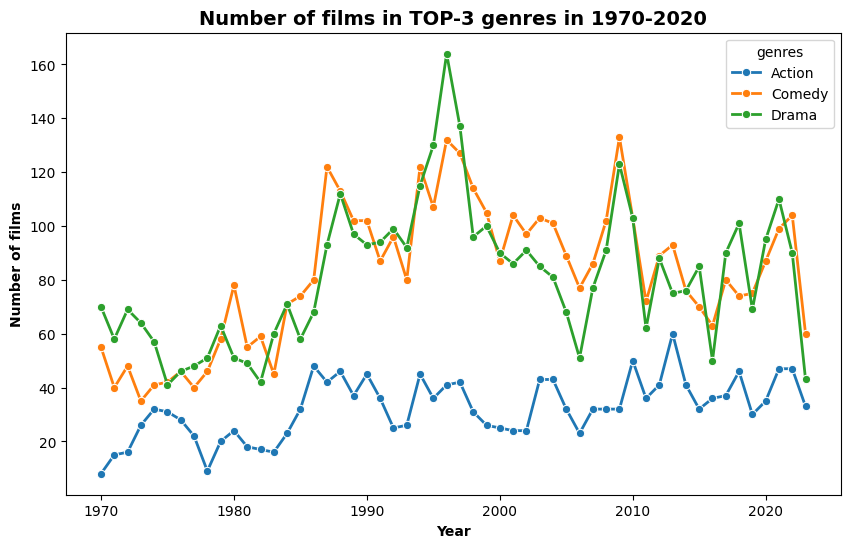

In [ ]:
#turn genres into Series
genres_exp = final_df['genres'].explode()
#defining top-3
top3_genres = genres_exp.value_counts().head(3).index.tolist()
print(f"Top-3 popular genres: {top3_genres}")
#unique indexes of films that are in top-3 genres
filtered_indexes = genres_exp[genres_exp.isin(top3_genres)].index.unique()
#print(filtered_indexes)
#filtering original (final after concat) dataframe for top-3 genres only
df_top3_genres = final_df.loc[filtered_indexes]
df_top3_genres.head(10)
#turn genres into Series for top 3
df_exploded_top3 = df_top3_genres.explode('genres')
#final filter (remove all genres that appear in the film next to the top 3)
df_final_trends = df_exploded_top3[df_exploded_top3['genres'].isin(top3_genres)].copy()
df_final_trends.head(10)
#grouping
film_counts_through_years = df_final_trends.groupby(['genres', 'year'])['title'].count().reset_index(name = 'movie_count')
print(film_counts_through_years)
#visualization
plt.figure(figsize = (10, 6))
sns.lineplot(data = film_counts_through_years,
             x = 'year',
             y = 'movie_count',
             hue = 'genres',
             marker = 'o',
             linewidth = 2)
plt.title(f"Number of films in TOP-3 genres in {decades_start}-{decades_end - 1}", fontweight = 'bold', fontsize = 14)
plt.xlabel("Year", fontweight = 'bold')
plt.ylabel("Number of films", fontweight = 'bold')
plt.show()

Тепер слід попрацювати з акторами. Віднайди топ 10 акторів за кількістю фільмів. Побудуй стовпчикову так кругову діаграму, а також виведи на екран підсумукову таблицю.

cast
Bruce Willis         104
Samuel L. Jackson     95
Robert De Niro        88
Dennis Quaid          72
Morgan Freeman        72
Liam Neeson           71
Robert Duvall         71
Nicolas Cage          71
Willem Dafoe          69
Donald Sutherland     69
Name: count, dtype: int64


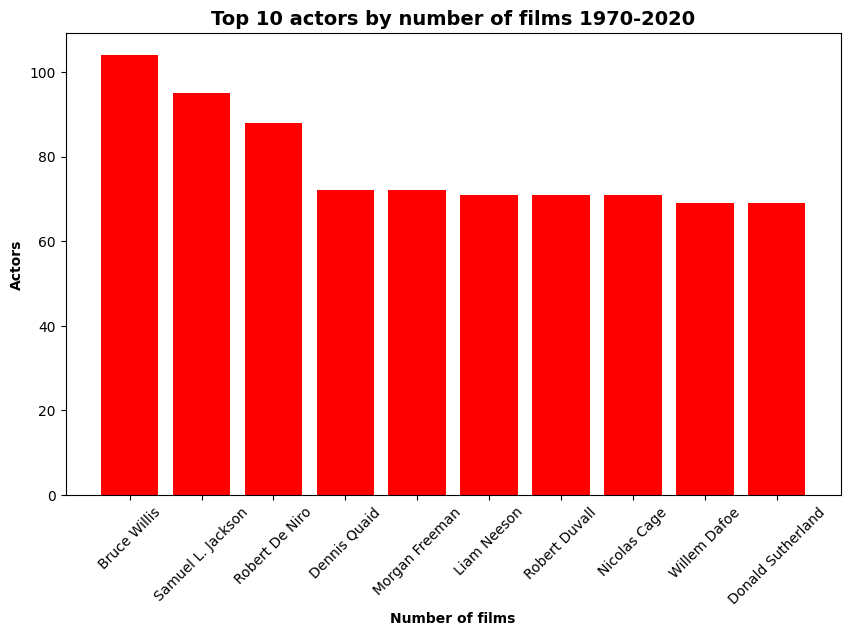

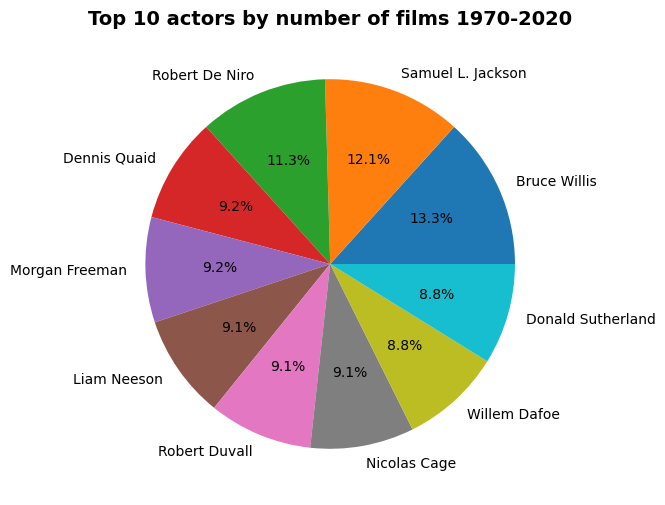

In [ ]:
#turn cast into Series
cast_exp = final_df['cast'].explode()
#defining top 10 actors
top10_actors = cast_exp.value_counts().head(10)
print(top10_actors)
#bar chart
plt.figure(figsize = (10, 6))
plt.bar(top10_actors.index, top10_actors.values, color = 'r')
plt.title(f"Top 10 actors by number of films {decades_start}-{decades_end-1}", fontweight = 'bold', fontsize = 14)
plt.xlabel("Number of films", fontweight = 'bold')
plt.ylabel("Actors", fontweight = 'bold')
plt.xticks(rotation = 45)
plt.show()
print("\n")
#pie chart
plt.figure(figsize = (10, 6))
plt.pie(top10_actors,
        labels = top10_actors.index,
        autopct='%1.1f%%')
plt.title(f"Top 10 actors by number of films {decades_start}-{decades_end-1}", fontweight = 'bold', fontsize = 14)
plt.show()

Тепер вибери 3 найпопулярніших актори і подивись, як змінювалась іх популярність впродовж обраного тобою часового періода. Для цього підрахуй кількість фільмів для кожного актора за кожен рік спостереження. Виведи результат у вигляді лінійного графіка.

Top-3 popular actors: ['Bruce Willis', 'Samuel L. Jackson', 'Robert De Niro']
                  cast  year  movie_count
0         Bruce Willis  1987            1
1         Bruce Willis  1988            2
2         Bruce Willis  1989            1
3         Bruce Willis  1990            3
4         Bruce Willis  1991            4
..                 ...   ...          ...
112  Samuel L. Jackson  2019            5
113  Samuel L. Jackson  2020            2
114  Samuel L. Jackson  2021            3
115  Samuel L. Jackson  2022            2
116  Samuel L. Jackson  2023            1

[117 rows x 3 columns]


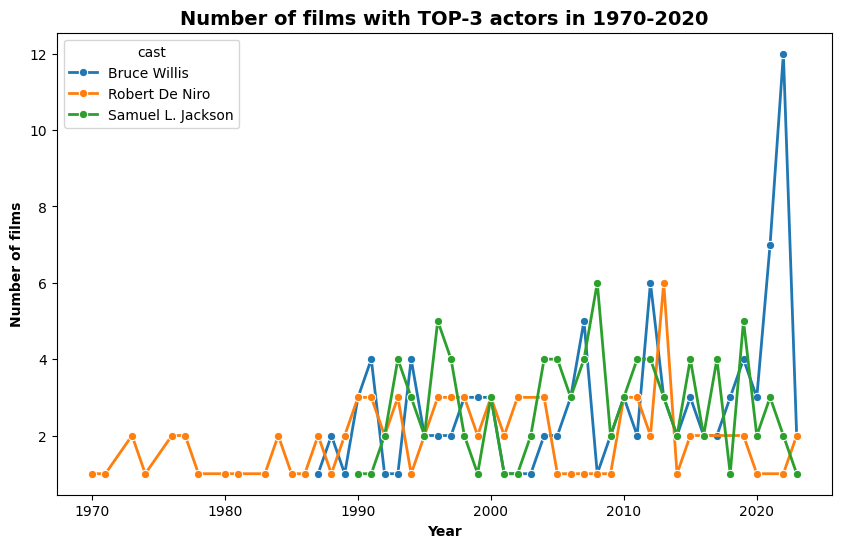

In [ ]:
#turn cast into Series
cast_exp = final_df['cast'].explode()
#defining top 3 actors
top3_actors = cast_exp.value_counts().head(3).index.tolist()
print(f"Top-3 popular actors: {top3_actors}")
#unique indexes of films that are with top-3 actors
filtered_indexes = cast_exp[cast_exp.isin(top3_actors)].index.unique()
#print(filtered_indexes)
#filtering original df for films with one of the top-3 actors only
df_top3_actors = final_df.loc[filtered_indexes]
df_top3_actors.head(10)
#turn cast into Series for top 3
df_exploded_top3 = df_top3_actors.explode('cast')
#final filter (remove all actors that appear in the film next to the top 3)
df_final_trends = df_exploded_top3[df_exploded_top3['cast'].isin(top3_actors)].copy()
df_final_trends.head(10)
#grouping
film_counts_through_years = df_final_trends.groupby(['cast', 'year'])['title'].count().reset_index(name = "movie_count")
print(film_counts_through_years)
#visualization
plt.figure(figsize = (10, 6))
sns.lineplot(data = film_counts_through_years,
             x = 'year',
             y = 'movie_count',
             hue = 'cast',
             marker = 'o',
             linewidth = 2)
plt.title(f"Number of films with TOP-3 actors in {decades_start}-{decades_end - 1}", fontweight = 'bold', fontsize = 14)
plt.xlabel("Year", fontweight = 'bold')
plt.ylabel("Number of films", fontweight = 'bold')
plt.show()

In [ ]:
#checking if it's a mistake that there are so many movies for Bruce in 2022
print(df_top3_actors[df_top3_actors['year'] == 2022])

                                  title  year  \
12318                    American Siege  2022   
12355                    Gasoline Alley  2022   
12359                      A Day to Die  2022   
12399            Fortress: Sniper's Eye  2022   
12401               Corrective Measures  2022   
12414                          Vendetta  2022   
12432                    White Elephant  2022   
12462  Paws of Fury: The Legend of Hank  2022   
12466                       Wrong Place  2022   
12507                         Wire Room  2022   
12548                         Amsterdam  2022   
12570           Detective Knight: Rogue  2022   
12593   Is That Black Enough for You?!?  2022   
12594                     Paradise City  2022   
12629      Detective Knight: Redemption  2022   

                                                    cast  \
12318                  [Timothy V. Murphy, Bruce Willis]   
12355            [Bruce Willis, Luke Wilson, Devon Sawa]   
12359         [Kevin Dillon, Bruce 

*Бонусне завдання*
Зосередьтеся лише на 10 найпопулярніших акторах. Порахуй, як часто кожен актор з'являється в фільмі, що належить до категорії топ-3 найпопулярніших жанри, а як часто в фільмі, що не включає топовий жанр.  Оціни пропорції для кожного актора у вигляді стовпчикової дфаграми та у вигляді таблиці, де вказано також відсоток фільмів в топ жанрах.

TOP-10 actors: ['Bruce Willis', 'Samuel L. Jackson', 'Robert De Niro', 'Dennis Quaid', 'Morgan Freeman', 'Liam Neeson', 'Robert Duvall', 'Nicolas Cage', 'Willem Dafoe', 'Donald Sutherland']
TOP-3 genres: ['Comedy', 'Drama', 'Action']
                   other_genre_count  top_3_genre_count  total_films  \
cast                                                                   
Bruce Willis                      16                 88          104   
Robert De Niro                    15                 73           88   
Dennis Quaid                      14                 58           72   
Liam Neeson                       17                 54           71   
Robert Duvall                     17                 54           71   
Nicolas Cage                      21                 50           71   
Donald Sutherland                 21                 48           69   
Morgan Freeman                    24                 48           72   
Samuel L. Jackson                 40          

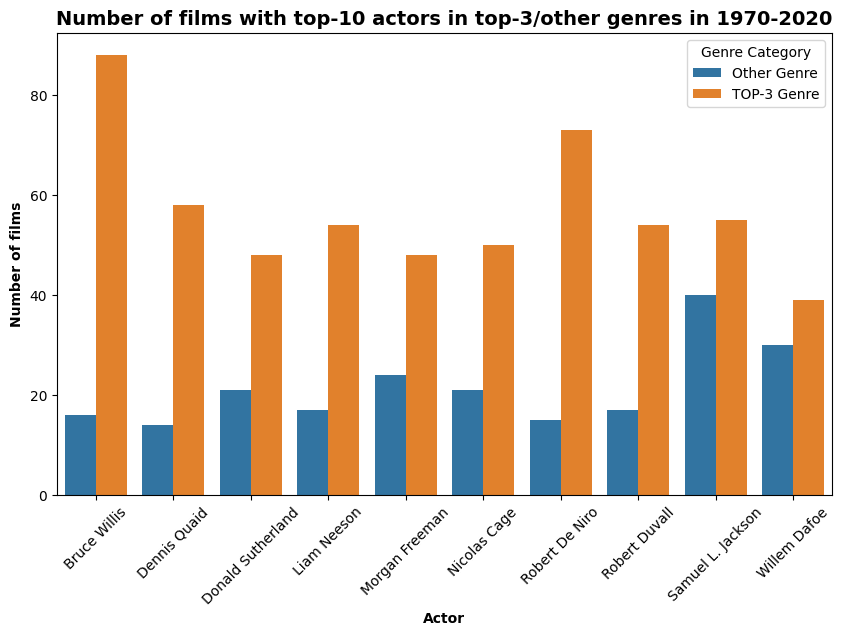

In [ ]:
from textwrap import fill
#defining top-10 actors
cast_exp = final_df['cast'].explode()
top10_actors = cast_exp.value_counts().head(10).index.tolist()
print(f"TOP-10 actors: {top10_actors}")
#defining top-3 genres
genres_exp = final_df['genres'].explode()
top3_genres = genres_exp.value_counts().head(3).index.tolist()
print(f"TOP-3 genres: {top3_genres}")
#creating column True/False if movie in top-3 genre
final_df['is_top_genre'] = final_df['genres'].apply(
    lambda x: any(g in top3_genres for g in x)
)
#final_df.head(10)

#filtering df with top-10 actors only
df_top10_actors = final_df[final_df['cast'].apply(
    lambda x: any(a in top10_actors for a in x)
)].copy()
#df_top10_actors.head(10)

#getting "Movie-Actor" relationship
df_top10_actors_exp = df_top10_actors.explode(['cast'])
#df_top10_actors_exp.head(10)

#Filtering for top-10 actors only
df_top10_actors_final = df_top10_actors_exp[df_top10_actors_exp['cast'].isin(top10_actors)]
#df_top10_actors_final.head(10)

#make a final table
actor_genre_counts = df_top10_actors_final.groupby(['cast','is_top_genre'])['title'].count().unstack(fill_value=0)
actor_genre_counts.columns = ['other_genre_count', 'top_3_genre_count']
actor_genre_counts['total_films'] = actor_genre_counts.sum(axis=1)
actor_genre_counts['top_genre_percentage'] = (actor_genre_counts['top_3_genre_count'] / actor_genre_counts['total_films']) * 100
actor_proportions_table = actor_genre_counts.sort_values(by='top_genre_percentage', ascending=False).round(2)
print(actor_proportions_table)
#visualization
plot_data = df_top10_actors_final.groupby(['cast','is_top_genre'])['title'].count().reset_index()
plot_data.columns = ['actor', 'genre_category', 'movie_count']
plot_data['genre_category'] = plot_data['genre_category'].replace(
    {False :'Other Genre',
     True : 'TOP-3 Genre'}
)
#print(plot_data)
print("\n")
plt.figure(figsize = (10, 6))
sns.barplot(data = plot_data,
            x = 'actor',
            y = 'movie_count',
            hue = 'genre_category')
plt.title(f"Number of films with top-10 actors in top-3/other genres in {decades_start}-{decades_end - 1}", fontweight = 'bold', fontsize = 14)
plt.xlabel("Actor", fontweight = 'bold')
plt.ylabel("Number of films", fontweight = 'bold')
plt.legend(title = "Genre Category")
plt.xticks(rotation = 45)
plt.show()